# **ResNet CIFAR-10**

### 각 코드 블럭을 실행하여 학습과 검증을 완료하고 코드 블럭 아래에 있는 서술형 문제(Q)에 답하시오.

**[Overview]**
1. 라이브러리 설정
2. GPU 설정
3. Data 준비
4. 모델 설계
5. 모델 훈련 (Training)
6. 모델 검증 (Testing)

**라이브러리**

In [23]:
import torch #pytorch 사용
import torch.nn as nn # neural network library from pytorch 사용
import torch.nn.functional as F # pytorch 내부의 F 함수 사용
import torch.optim as optim # optimizer 사용
import torchvision
from torchvision import datasets, transforms  #dataset 불러오기 위해 사용
import matplotlib.pyplot as plt # 시각화를 위한 matplotlib 사용
from torch.utils.data import DataLoader #Data를 batch_size로 나누기 위해 사용
from tqdm.notebook import tqdm

**GPU 설정**
 - cpu: 최대 24코어
 - gpu: 단순한 연산(floating point) 덧셈 뺄셈 곱셈 나눗셈만 이것만 전문으로 하는 코어들을 수천개씩 가지고 있다
 - 딥러닝은 기본적으로 행렬 곱하기 연산이기 때문에 딥러닝에는 gpu가 적합하다

In [24]:
! nvidia-smi
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

Wed Aug 13 13:35:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             31W /   70W |    1590MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Data 준비**

In [25]:
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Transform 정의
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# CIFAR10 TRAIN 데이터 정의
cifar10_train = datasets.CIFAR10(root="../Data/", train=True, transform=transform, target_transform=None, download=True)

train_loader = torch.utils.data.DataLoader(cifar10_train, batch_size=128, shuffle=True)

# CIFAR10 TEST 데이터 정의
cifar10_test = datasets.CIFAR10(root="../Data/", train=False, transform=transform, target_transform=None, download=True)
test_loader = torch.utils.data.DataLoader(cifar10_test, batch_size=128)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

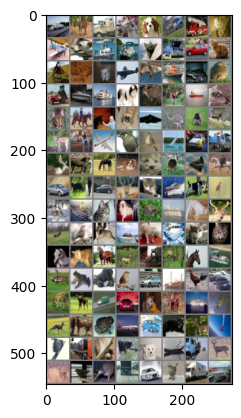

truck deer  truck horse


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 이미지를 보여주기 위한 함수

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# 학습용 이미지를 무작위로 가져오기
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))


**VGG 모델 설계**

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Residual Block 구조 정의 -> ResNet-18 / ResNet-34
class BasicBlock(nn.Module):
    mul = 1  # 채널 확장 비율(곱) - BasicBlock은 그대로 1
    def __init__(self, in_planes, out_planes, stride=1):
        super(BasicBlock, self).__init__()

        # 첫 번째 3x3 Convolution
        # stride를 통해 너비와 높이 조정
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_planes)

        # 두 번째 3x3 Convolution (stride=1 고정 -> 크기 그대로)
        # stride = 1, padding = 1이므로, 너비와 높이는 항시 유지됨
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)

        # 기본적으로 identity shortcut 사용
        # x를 그대로 더해주기 위함
        self.shortcut = nn.Sequential()

        # projection shortcut 생성 조건(BasicBlock):
        # 만약 size가 안맞아 합연산이 불가하다면, 연산 가능하도록 모양을 맞춰줌
        if stride != 1: # feature map 크기 다름 -> 1x1 conv로 크기/채널 맞춤
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_planes)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        # shortcut(x) : stride나 채널 차이에 맞춰 projection 또는 identity 수행
        out += self.shortcut(x) # 필요에 따라 layer를 Skip
        out = F.relu(out)
        return out

# BottleNeck 블록 (ResNet-50 이상)
class BottleNeck(nn.Module):
    mul = 4  # 채널 확장 비율 (1x1 conv에서 out_planes x 4로 확장)
    def __init__(self, in_planes, out_planes, stride=1):
        super(BottleNeck, self).__init__()

        # 첫 번째 1x1 Convolution : 채널 수 축소 및 stride로 downsampling 가능
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)
        self.bn1 = nn.BatchNorm2d(out_planes)

        # 두 번째 3x3 Convolution : 공간적 특징 추출 (크기 그대로)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)

        # 세 번째 1x1 Convolution : 채널 수 확장 ( out_planes -> out planes x 4)
        self.conv3 = nn.Conv2d(out_planes, out_planes*self.mul, kernel_size=1, stride=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_planes*self.mul)

        # 기본 shortcut : identity
        self.shortcut = nn.Sequential()

        # projection shortcut 생성 조건(BottleNeck):
        if stride != 1 or in_planes != out_planes*self.mul: # 공간 크기 다르거나 채널 수 다르면
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes*self.mul, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_planes*self.mul)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = F.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        # projection 또는 identity shortcut 더하기
        out += self.shortcut(x)
        out = F.relu(out)
        return out





class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        # RGB 3개 채널에서 64개의 Kernel 사용
        self.in_planes = 64

        # Resnet 논문 구조 그대로 구현 -> 초기 conv + 4개의 stage + 평균 풀링 + FC
        self.conv1 = nn.Conv2d(3, self.in_planes, kernel_size=7, stride=2, padding = 3)
        self.bn1 = nn.BatchNorm2d(self.in_planes)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 각 stage 구성 : 채널 수 증가 & 크기 절반 감소
        self.layer1 = self.make_layer(block, 64, num_blocks[0], stride=1)  # 크기 그대로
        self.layer2 = self.make_layer(block, 128, num_blocks[1], stride=2)  # 해상도 절반
        self.layer3 = self.make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self.make_layer(block, 512, num_blocks[3], stride=2)
        # 평균 풀링 후 Fully Connected Layer
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.linear = nn.Linear(512 * block.mul, num_classes)

        # stage 내부 블록 구성
    def make_layer(self, block, out_planes, num_blocks, stride):
        # layer 앞부분에서만 크기를 절반으로 줄이므로, 아래와 같은 구조
        strides = [stride] + [1] * (num_blocks-1)  # 첫 블록 입력받고 나머지 블록은 stride 1 유지
        layers = []
        for i in range(num_blocks):
            layers.append(block(self.in_planes, out_planes, strides[i]))
            # 다음 블록 입력 채널 크기 갱신
            self.in_planes = block.mul * out_planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.maxpool1(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out,1)
        out = self.linear(out)
        return out


def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])  # []은 각 블록개수

def ResNet34():
    return ResNet(BasicBlock, [3, 4, 6, 3])

def ResNet50():
    return ResNet(BottleNeck, [3, 4, 6, 3])

def ResNet101():
    return ResNet(BottleNeck, [3, 4, 23, 3])

def ResNet152():
    return ResNet(BottleNeck, [3, 8, 36, 3])

In [28]:
device = 'cuda'
model = ResNet50()
model = model.to(device)
# ResNet18, ResNet34, ResNet50, ResNet101, ResNet152 중에 택일하여 사용
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BottleNeck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affi

### Q. 위 ResNet 구현에서 projection shortcut이 적용되는 지점을 "코드 위치"와 “모델 스테이지별 발생 구간”의 두 관점으로 설명하시오.

단서는 다음과 같다.

	•	Identity shortcut 충분: H X W, 채널, stride가 모두 동일한 블록.
	•	Projection 필요: (1) stride 변경으로 공간 크기 달라짐, (2) 채널 수가 변함, (3) 정렬·scale 차이를 보정해야 함.


요구사항:

  1.	projection을 생성하는 조건을 만족하는 코드를 정확히 인용(또는 요약)하라.

  2.	ResNet-18/34와 ResNet-50/101/152에서 어느 스테이지의 어느 블록에서 projection이 쓰이는지, 이 코드의 make_layer 로직(첫 블록 stride 설정)과 함께 설명하라.

**YOUR ANSWER 1.**


1. BasicBlock
```
if stride != 1:
    self.shortcut = nn.Sequential(
    nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False),
    nn.BatchNorm2d(out_planes)
)
```
=> stride != 1 -> 공간 크기 변화 -> projection 생성


2. BottleNeck
```
if stride != 1 or in_planes != out_planes*self.mul:
    self.shortcut = nn.Sequential(
    nn.Conv2d(in_planes, out_planes*self.mul, kernel_size=1, stride=stride, bias=False),
    nn.BatchNorm2d(out_planes*self.mul)
)
```
=> stride != 1 또는 in_planes != out_planes*mul(mul=4) -> 공간 크기 변화 or 채널 불일치 -> projection 생성


3. make_layer
```
strides = [stride] + [1] * (num_blocks-1)
    for i in range(num_blocks):
    layers.append(block(self.in_planes, out_planes, strides[i]))
    self.in_planes = block.mul * out_planes
```
=> 각 stage의 첫 블록만 전달받은 stride 적용 (나머지는 stride 1로 통일) -> projection 조건이 생기면 첫 블록에서만 발생



**YOUR ANSWER 2**

- 모델별 설정
```
ResNet-18: block=BasicBlock(mul=1), num_blocks=[2,2,2,2]
ResNet-34: block=BasicBlock(mul=1), num_blocks=[3,4,6,3]
ResNet-50: block=BottleNeck(mul=4), num_blocks=[3,4,6,3]
ResNet-101: block=BottleNeck(mul=4), num_blocks=[3,4,23,3]
ResNet-152: block=BottleNeck(mul=4), num_blocks=[3,8,36,3]
```

여기서 BasicBlock과 BottleNeck은 위에서 언급한 조건 때 projection이 발생함.

- ResNet-18 / 34 (BasicBlock) 모델의 경우
```
layer1: stride=1 -> projection 없음
layer2: block0 (stride=2) -> projection
layer3: block0 (stride=2) -> projection
layer4: block0 (stride=2) -> projection
나머지 블록들은 전부 stride=1 -> identity
```
- ResNet-50 / 101 / 152 (BottleNeck, mul=4) 모델의 경우
```
layer1: block0 (stride=1이지만 in_planes(64) != out_planes*mul(64*4=256) 채널 불일치) -> projection
layer2: block0 (stride=2 + 채널 증가) -> projection
layer3: block0 (stride=2 + 채널 증가) -> projection
layer4: block0 (stride=2 + 채널 증가) -> projection
각 stage의 나머지 블록들: stride=1이고 채널도 이미 맞음 -> identity
```

- 여기서 make_layer 로직을 살펴보면

```
strides = [stride] + [1] * (num_blocks-1)
```
- stage를 만들 때 첫 블록만 인자로 받은 stride(layer1=1, layer2=2, layer3=2, layer4=2)를 쓰고, 나머지 블록은 모두 stride=1임
- 예) ResNet-34의 layer3(블록 6개): strides = [2,1,1,1,1,1]
- 따라서 projection 발생 조건에 부합하면 make_layer 로직에 의해 항상 각 stage의 첫 블록에서만 발생함




**Hyperparameter 설정**

In [29]:
epochs = 30
lr = 2e-4

# seed
seed = 2891
torch.manual_seed = seed  #매번 같은 결과 값이 나오게 함

loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


In [30]:
from torchsummary import summary
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 16, 16]           9,472
       BatchNorm2d-2           [-1, 64, 16, 16]             128
         MaxPool2d-3             [-1, 64, 8, 8]               0
            Conv2d-4             [-1, 64, 8, 8]           4,096
       BatchNorm2d-5             [-1, 64, 8, 8]             128
            Conv2d-6             [-1, 64, 8, 8]          36,864
       BatchNorm2d-7             [-1, 64, 8, 8]             128
            Conv2d-8            [-1, 256, 8, 8]          16,384
       BatchNorm2d-9            [-1, 256, 8, 8]             512
           Conv2d-10            [-1, 256, 8, 8]          16,384
      BatchNorm2d-11            [-1, 256, 8, 8]             512
       BottleNeck-12            [-1, 256, 8, 8]               0
           Conv2d-13             [-1, 64, 8, 8]          16,384
      BatchNorm2d-14             [-1, 6

### Q. 위 summary를 보고 문제에 답하시오.

(a) 테이블에서 임의의 Bottleneck(예: 첫 스테이지의 첫 블록)을 하나 고르고, 그 안의 세 개 conv(1×1, 3×3, 1×1) 가중치 수를 직접 계산하라. (bias=False, BN 파라미터는 별도 집계)

(b) 같은 블록의 shortcut 분기가 projection인지 identity인지 판별하고, projection인 경우 1×1 conv의 파라미터 수도 계산하라.

(c) 같은 스테이지 내 identity shortcut만 쓰는 블록도 예시로 2개 골라, 해당 블록에서 identity가 충분한 이유를 코드/형상 관점에서 서술하라.


**YOUR ANSWER (a)**

```
Conv2d-4 : 1×1, 64->64, params 4,096
=> 64×64×1×1=4,096

Conv2d-6 : 3×3, 64->64, params 36,864
=> 64×64×3×3=64×64×9=36,864

Conv2d-8 : 1×1, 64->256, params 16,384
=> 256×64×1×1=16,384

```



**YOUR ANSWER (b)**

- 같은 블록의 shortcut 종류 : projection
```
Conv2d-10 : 1×1, 64->256, params 16,384
=> 256×64×1×1=16,384
```

=> stride=1이라 공간 크기는 같지만, 채널이 64 -> 256으로 불일치라서 1×1 conv로 맞춰주는 projection 진행



**YOUR ANSWER (c)**

```
block1 : Conv2d-13 ~ BatchNorm2d-18  
block2 : Conv2d-20 ~ BatchNorm2d-25  
=> projection용 Conv2d가 없으므로 identity shortcut  
```

- stride=1이며 입력/출력 채널이 모두 256이고 공간 크기도 8×8로 동일해 코드의 projection 생성 조건(크기 변화 또는 채널 불일치)에 해당하지 않음


**Model 훈련(Training)**

In [31]:

tot_train_loss= []

for e in range(1, epochs+1):
    model.train()
    print(f"============= [Epochs] {e}/{epochs} =============")
    train_loss = 0.0
    for datas, labels in tqdm(train_loader):
        datas = datas.to(device)
        labels = labels.to(device)

        output = model(datas)
        loss = loss_fn(output, labels)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    tot_train_loss.append(train_loss/len(train_loader))
    print(f"Loss: {train_loss/len(train_loader):.6f}")

    # 매 에폭마다 성능 차이를 보기 위해 실행
    with torch.no_grad(): # autograd 엔진을 비활성화
        model.eval() # dropout을 비활성화 시켜줌
        test_acc = 0.0
        for datas, labels in tqdm(test_loader):

            datas = datas.to(device)
            labels = labels.to(device)

            output = model(datas)

            preds = torch.argmax(output, dim=1)
            test_acc += preds.eq(labels).sum()

    print(f"[Epoch] {e}, [Test Result] {(test_acc/len(test_loader.dataset))*100:.3f}%")


============= [Epochs] 1/30 =============


  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 1.821525


  0%|          | 0/79 [00:00<?, ?it/s]

[Epoch] 1, [Test Result] 45.830%
============= [Epochs] 2/30 =============


...

[Epoch] 29, [Test Result] 68.240%
============= [Epochs] 30/30 =============


  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 0.094167


  0%|          | 0/79 [00:00<?, ?it/s]

[Epoch] 30, [Test Result] 67.930%


**7. Model 검증(Testing)**
* 모델이 잘 학습되었는지 검증

In [32]:
with torch.no_grad(): # autograd 엔진을 비활성화
    model.eval() # dropout을 비활성화 시켜줌
    test_acc = 0.0
    for datas, labels in tqdm(test_loader):

        datas= datas.to(device)
        labels= labels.to(device)

        output= model(datas)

        preds= torch.argmax(output, dim=1)
        test_acc+= preds.eq(labels).sum()

print(f"[Test Result] {(test_acc/len(test_loader.dataset))*100:.3f}%")

  0%|          | 0/79 [00:00<?, ?it/s]

[Test Result] 67.930%


## 추가 문제 (PPT 관련)

### Q. 다음 중 Shortcut Connection이 필요한 이유로 가장 적절하지 않은 것은 무엇인가요?

A. 입력 정보를 그대로 다음 레이어에 전달하기 위해

B. 깊은 네트워크에서도 gradient가 잘 흐르도록 하기 위해

C. 연산량을 줄이기 위해

D. 입력과 출력의 차원이 다를 때 덧셈을 가능하게 하기 위해


**YOUR ANSWER**:

```
C. 오히려 1x1 projection 등은 연산을 추가하는 구조
```

### Q. ResNet-18, ResNet-34, ResNet-50과 같은 다양한 ResNet 버전들이 존재한다.

이러한 버전들이 무엇을 의미하며, 왜 다양한 버전이 사용되는지 서술하라.

**YOUR ANSWER**:\
모델의 버전은 네트워크 전체 layer 수를 의미합니다. ResNet-18은 18층을, ResNet-50은 bottleneck 블록을 포함하여 50층을 이룹니다. 이렇게 다양한 모델의 버전이 필요한 이유에는 4가지가 있습니다.
1. Depth에 따른 성능 변화
모델의 깊이만 늘린다고 무조건적으로 성능이 올라가지 않으며 환경과 목적에 맞도록 깊이를 선택해야 합니다.
2. 리소스 및 하드웨어 제약
깊이가 깊을수록 연산량과 메모리 사용량이 증가합니다. 비교적 얕은 모델은 빠르고 경량적이고 깊은 모델은 높은 정확도를 달성할 수 있기에 환경에 맞는 모델을 선택해야 합니다.
3. 과적합 방지
데이터셋 규모에 따라 안정적인 성능을 내는 모델을 선택해야 합니다.

**YOUR ANSWER**:

1. ResNet 버전들의 숫자는 전체 네트워크의 층 수를 의미함
2. 다양한 모델 버전이 필요한 이유
- 제한된 연산·메모리 환경에서는 경량 모델로 속도를, 고성능 환경에서는 더 깊은 모델로 정확도를 극대화함
- BasicBlock으로 단순함을 살린 얕은 버전과 Bottleneck으로 효율을 끌어올린 깊은 버전으로 성능과 연산량을 정교하게 조율함